In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import numba as nb
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [2]:
def plot_trajectory(ts, init_points, params, fig_size=(10, 10), **results):
    dim_labels = [r'$u_{\rm e}^1$', r'$u_{\rm i}^1$', r'$u_{\rm e}^2$', r'$u_{\rm i}^2$']

    fp = results.get('fps')

    fig, axes = plt.subplots(1, 2, figsize=fig_size)

    # Plotting the vector field in the state space (E, I)
    axes[0].set_ylabel(dim_labels[0], rotation=0, labelpad=15, fontsize=20);
    axes[0].set_xlabel(dim_labels[1], fontsize=20)

    axes[1].set_ylabel(f"{dim_labels[2]} - {dim_labels[0]}", labelpad=15, fontsize=20);
    axes[1].set_xlabel(f"{dim_labels[3]} - {dim_labels[1]}", fontsize=20)

    x0_, x1_, x2_, x3_ = init_points

    for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
        kts = ts[k, :, :]
   
        # Plot the solution in the state space
        axes[0].plot(kts[1, :], kts[0, :], 'b--', alpha=.4)
        axes[0].scatter(y0[1], y0[0], marker='.', c='k', s=200, label=f"{dim_labels[0]} = {y0[0]:.3f}, {dim_labels[1]} = {y0[1]:.3f}")
        axes[1].plot(kts[3, :] - kts[1, :], kts[2, :] - kts[0, :], 'b--', alpha=.4)
        axes[1].scatter(y0[3] - y0[1], y0[2] - y0[0], marker='.', c='k', s=200,
                           label=f"{dim_labels[2]} - {dim_labels[0]} = {y0[2] - y0[0]:.3f}, {dim_labels[3]} - {dim_labels[1]} = {y0[3] - y0[1]:.3f}")
    
    # Plot the fixed points identified
    if len(fp) > 0:
        fp = fp.T
        eval_dict = calc_jacobian(fp, **params)
        colors = eval_dict['types']
        for i in range(results['n_fps']):
            axes[0].scatter(fp[i, 1], fp[i, 0], marker='*', c=colors[i], s=200, label=f"Fixed points")
            axes[1].scatter(fp[i, 3] - fp[i, 1], fp[i, 2] - fp[i, 0], marker='*', c=colors[i], s=200, label=f"Fixed points")
        
    for pos in ['right', 'top', 'bottom', 'left']:
        axes[0].spines[pos].set_visible(False)
        axes[1].spines[pos].set_visible(False)

    fig.align_ylabels()
    fig.tight_layout()

    plt.show()
    return

In [3]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5/ params['gamma']
grid_res = 100
n_trials = 5

params['D0'] = 0.000 / (params['gamma'] * params['gamma'])

In [4]:
# Initialization points
np.random.seed(0)
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

## Variables to analyze
params['K'] = 0.2
params['i_e1'] = 0.25 / params['gamma']

DT = np.array([0.1, 0.01, 0.005, 0.0025])
sVals = np.array([2.5, 7.5, 12.5])

## Plotting variables
nTrial = 0


In [5]:
def plotLyapunov(lyapResults, tArr, fig_size=(10, 2)):

    plt.figure(figsize = fig_size)
    minValue = min(lyapResults[lyapResults != -np.inf])
    lyapResults[lyapResults == -np.inf] = minValue

    plt.plot(tArr, lyapResults, 'k', alpha=0.8, linewidth=.8)
    plt.axhline(y=0.0, color='r', linestyle='-')
    plt.xlabel('Time (ms)', fontsize=18, labelpad=15); plt.ylabel(r"$\ell_e$", rotation=0, labelpad=10, fontsize=20)
    plt.xlim([0, 1500])
    plt.xticks(np.arange(0, tArr[-1] + 1, 500))

    for pos in ["right", "top", "bottom", "left"]:
        plt.gca().spines[pos].set_visible(False)
        plt.gca().spines[pos].set_visible(False)

    plt.title(r"$\overline{\ell}_e = $" + f"{np.mean(lyapResults):.2f}", fontsize=20)
    plt.show()
    return

def plotTS(u, tArr, fig_size=(10, 2), nTrials = n_trials):
       
    colors = plt.get_cmap("Blues")
    colorIter = iter(colors(np.linspace(0.3, 0.75, nTrials)))
    plt.figure(figsize = fig_size)
    
    for j in range(nTrials):
        plt.plot(tArr, u[j, :], color = next(colorIter), linewidth=1.2, label=f"Trial {j + 1}")
    
    plt.plot(tArr, np.mean(u, axis=0), color="k", alpha=0.75, linewidth=0.8, label="Avg. dynamics")
    
    plt.xlabel('Time (ms)', fontsize=18, labelpad=15); plt.ylabel(r"$u_{\rm e}^1$", rotation=0, labelpad=10, fontsize=18)
    plt.xlim([0, 1500])
    plt.xticks(np.arange(0, tArr[-1], 500))

    for pos in ["right", "top", "bottom", "left"]:
        plt.gca().spines[pos].set_visible(False)
        plt.gca().spines[pos].set_visible(False)
    
    plt.legend(ncols=3, bbox_to_anchor = (0.9, -0.6), fontsize=16, frameon=False)

    plt.show()
    return

In [6]:
@nb.njit()
def calcLyapunov(u, dt, T, n_trials=n_trials):
    results = np.zeros((n_trials, T - 1))
    for j in range(n_trials):
        _diff = np.abs(np.diff(u[j, 0, :])) / (dt * 10)
        results[j, :] = np.log(_diff)
    return results

Running simulation for dt = 1.0ms
Running simulation for sig = 2.5


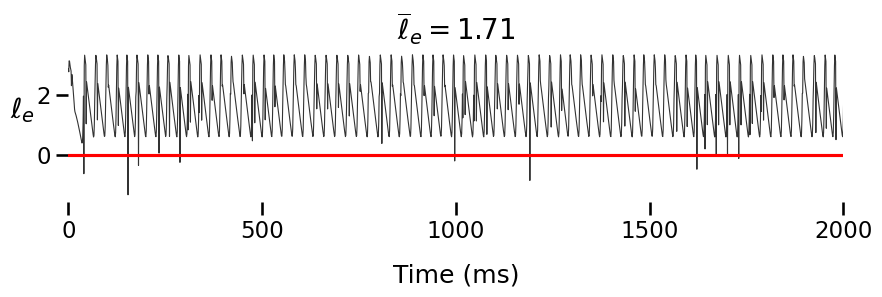

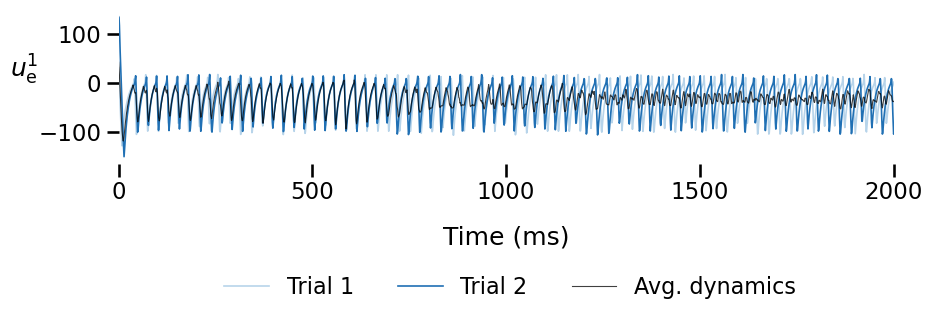

Running simulation for sig = 7.5


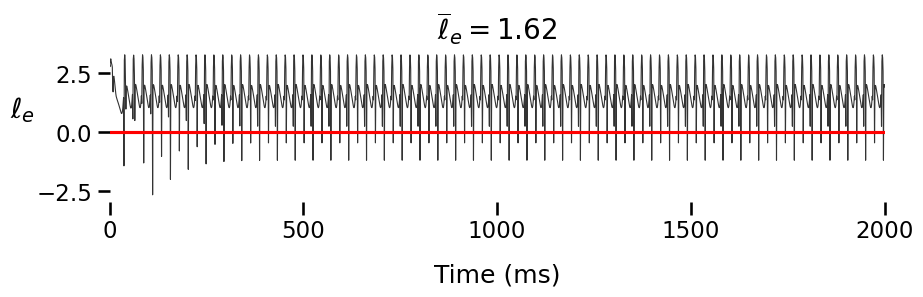

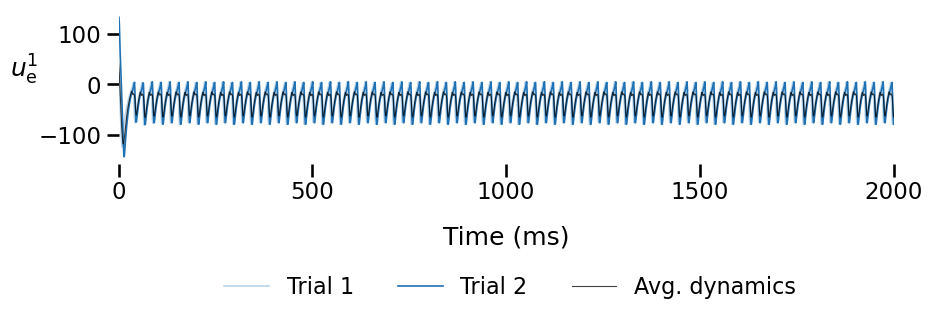

Running simulation for sig = 12.5


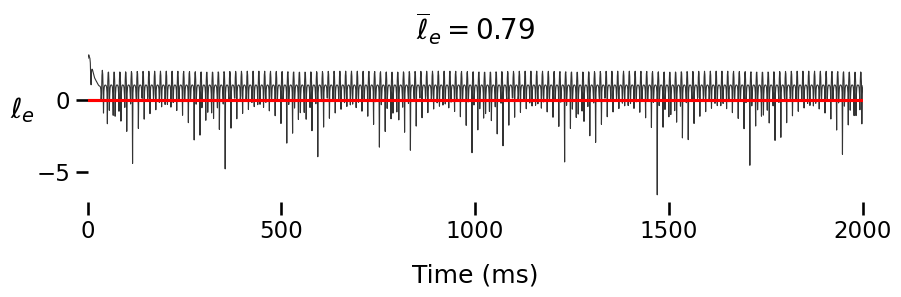

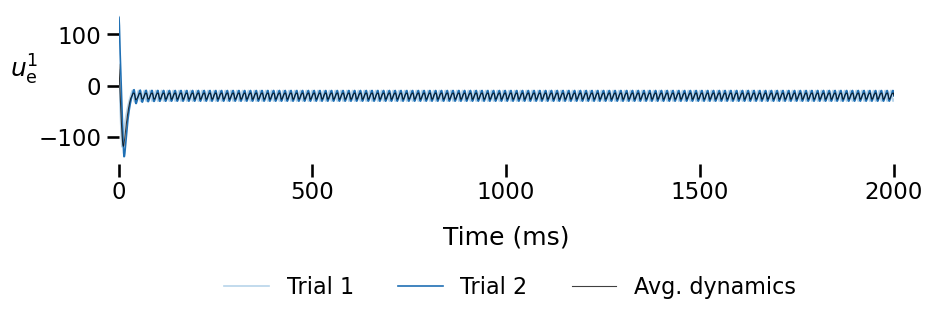

Running simulation for dt = 0.1ms
Running simulation for sig = 2.5


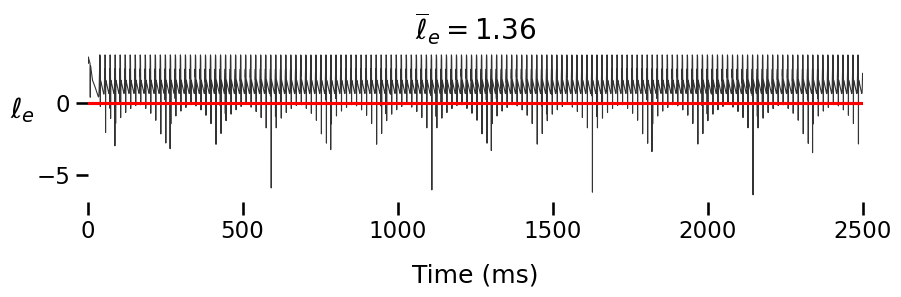

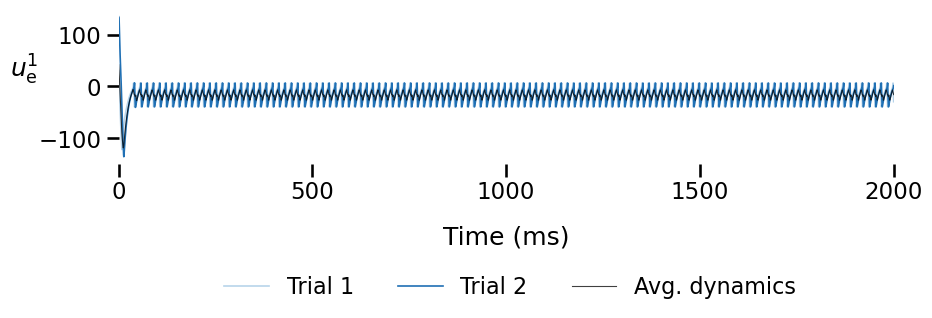

Running simulation for sig = 7.5


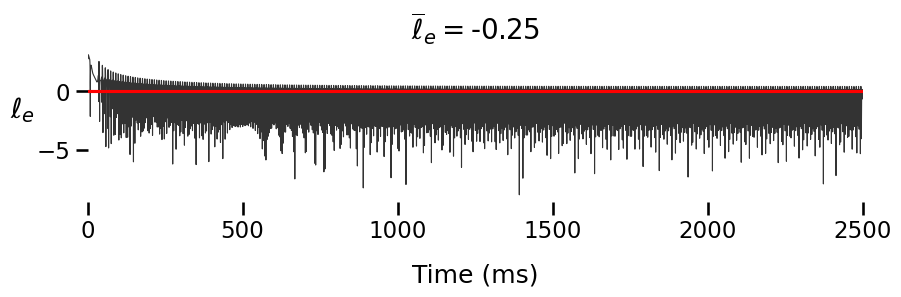

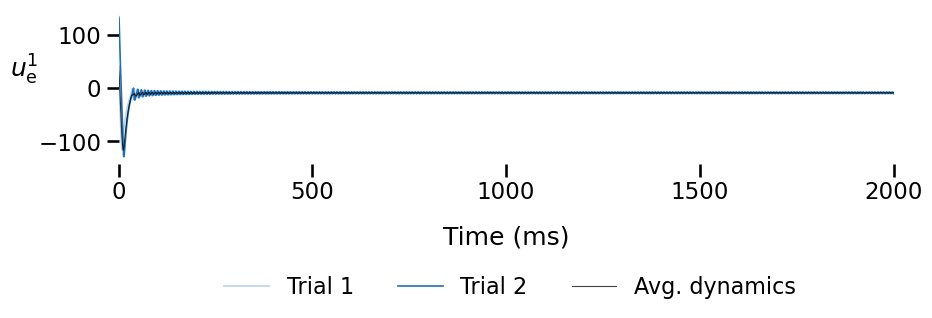

Running simulation for sig = 12.5


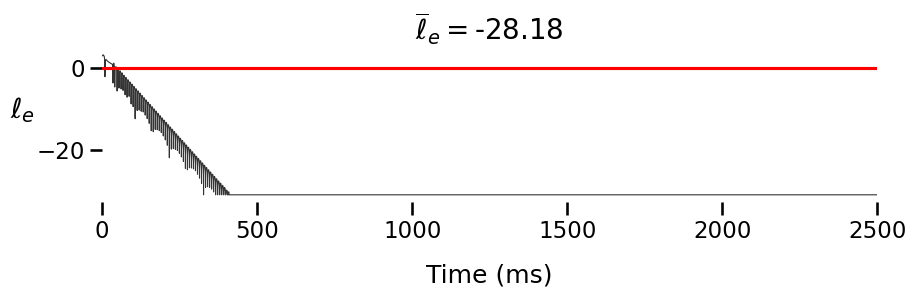

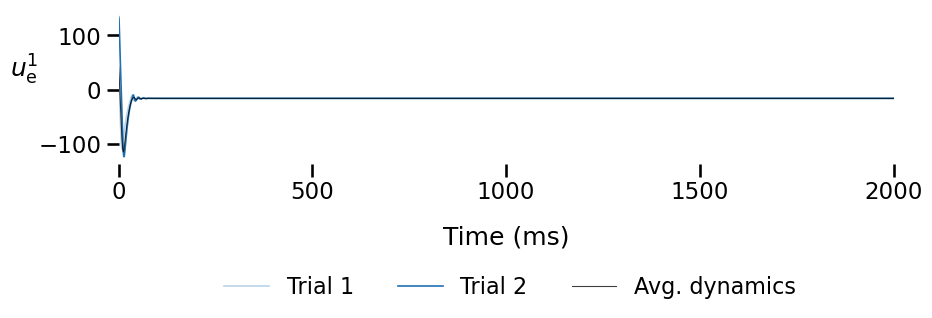

Running simulation for dt = 0.05ms
Running simulation for sig = 2.5


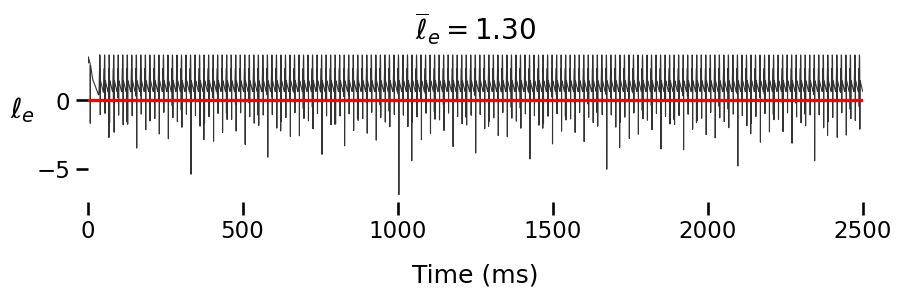

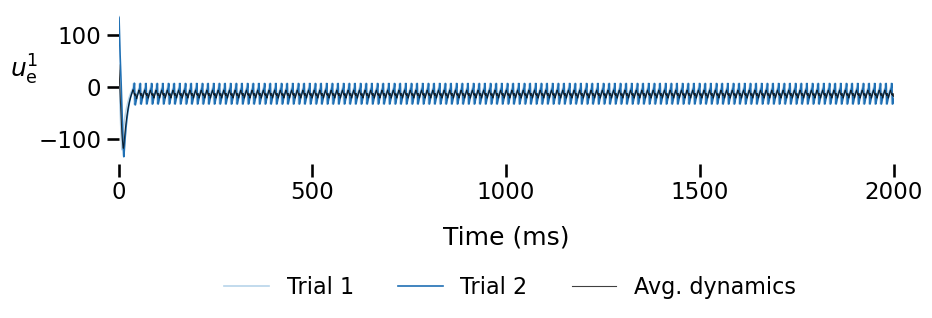

Running simulation for sig = 7.5


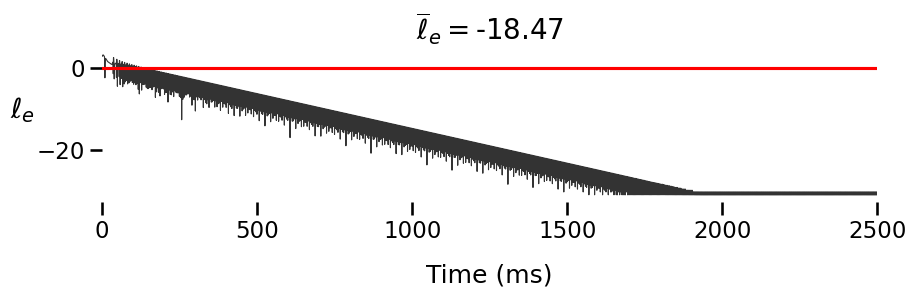

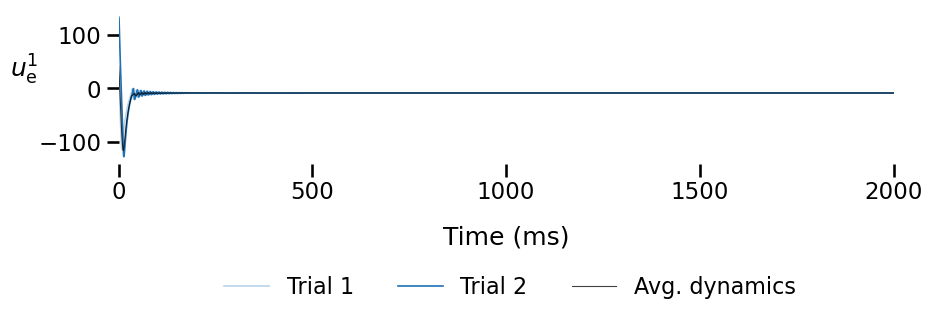

Running simulation for sig = 12.5


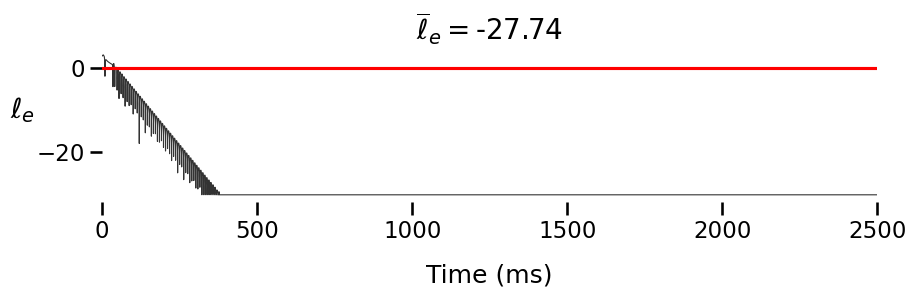

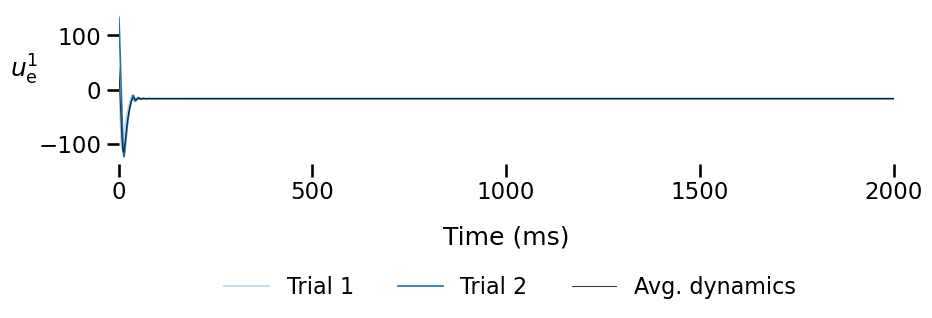

Running simulation for dt = 0.025ms
Running simulation for sig = 2.5


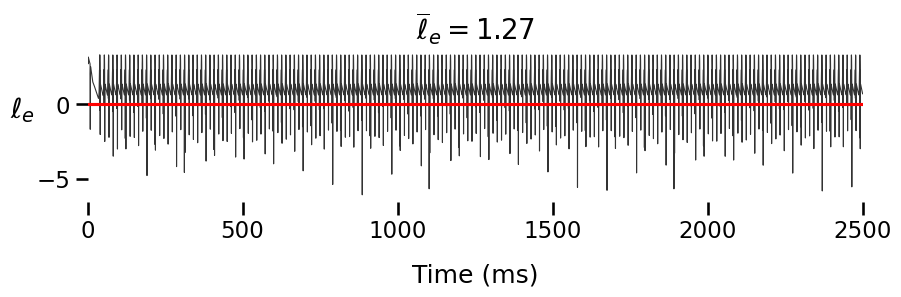

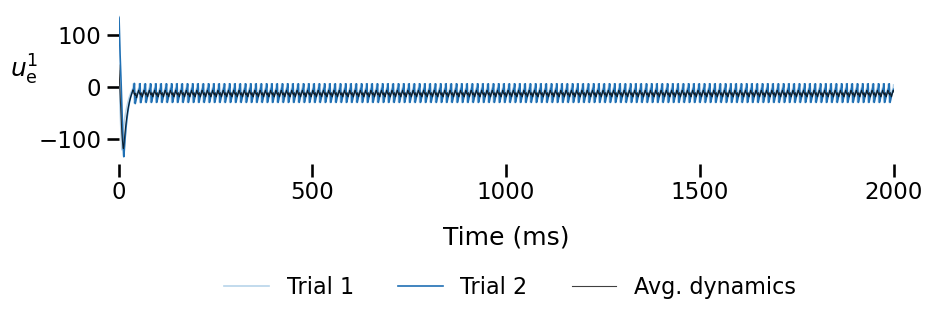

Running simulation for sig = 7.5


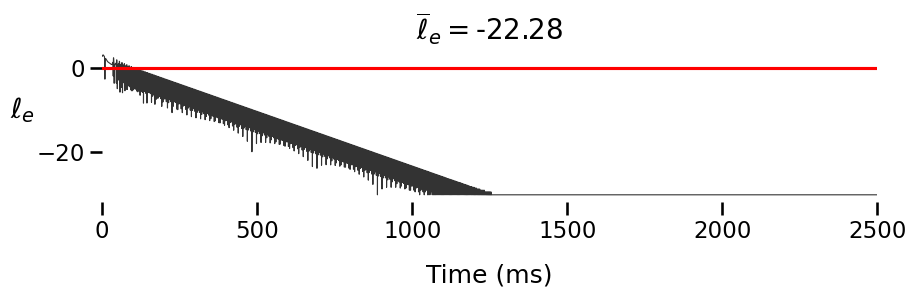

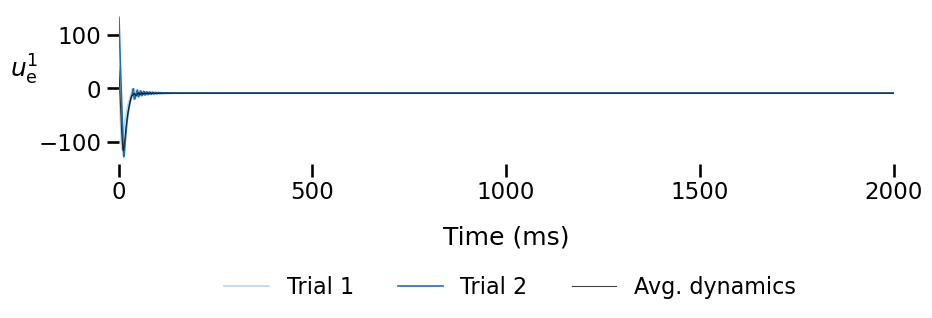

Running simulation for sig = 12.5


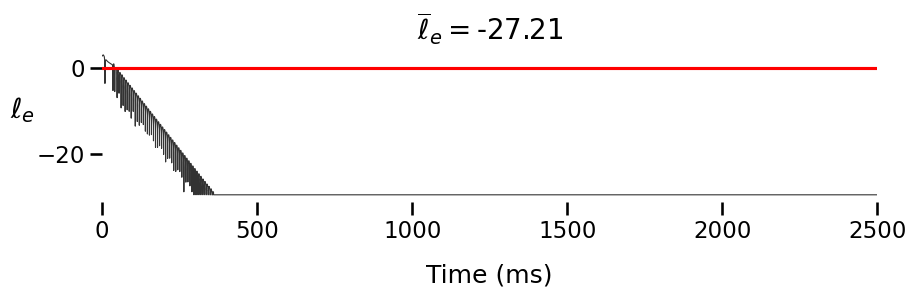

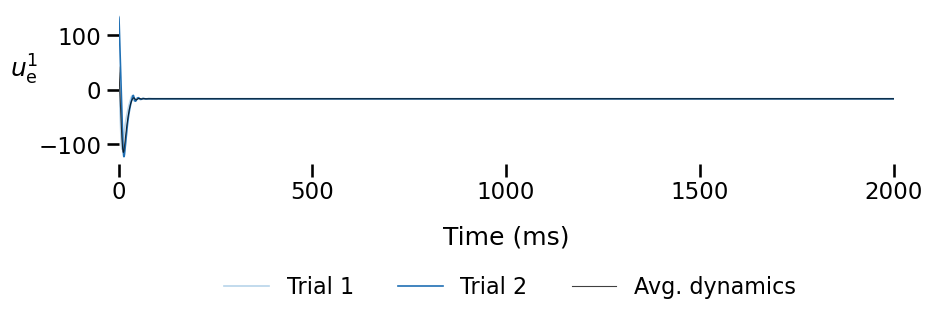

In [7]:
for tn, dt in enumerate(DT):
    print(f"Running simulation for dt = {dt * 10}ms")
    # time vector
    params['dt'] = dt

    T = params['T'] = int(2500 / (params['dt'] * 10))
    tspan = np.arange(0, T) * (params['dt'] * 10)

    t_start = int(500 / (params['dt'] * 10))
    t_end = T

    for sn, sig in enumerate(sVals):
        print(f"Running simulation for sig = {sig}")
        params['sig_e1'] = params['sig_e2'] = sig
        params['sig_i1'] = params['sig_i2'] = sig

        u = np.zeros((n_trials, 4, T))
        u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

        lyapResults = calcLyapunov(u, dt, T, n_trials)
        ## Single trial plotting
        plotLyapunov(lyapResults = lyapResults[nTrial, :], tArr=tspan[:-1], fig_size=(10, 2))
        plotTS(u = u[:, 0, :], tArr=tspan, fig_size=(10, 2), nTrials = 2)     